Initializing fiducial ΛCDM cosmology with CAMB...
Done.

BAO ROBUSTNESS ANALYSIS: LINDER (2007) MIRAGE EFFECT

Linder CMB mirage:
  Coefficient A = 3.679
  Crossover a_w = 0.728 (z_w = 0.37)
  CMB mirage line: wa = -3.68 * (1 + w0)

DESI DR2 D_M/r_d measurements:
  LRG1: DM/rd @ z=0.51
  LRG2: DM/rd @ z=0.706
  LRG3+ELG1: DM/rd @ z=0.934
  ELG2: DM/rd @ z=1.321
  QSO: DM/rd @ z=1.484
  Lya: DM/rd @ z=2.33

DESI DR2 D_H/r_d measurements:
  LRG1: DH/rd @ z=0.51
  LRG2: DH/rd @ z=0.706
  LRG3+ELG1: DH/rd @ z=0.934
  ELG2: DH/rd @ z=1.321
  QSO: DH/rd @ z=1.484
  Lya: DH/rd @ z=2.33

BAO D_M mirage parameters:
  z=0.510: A0=0.1535, Aa=0.0183, slope=-8.376
           BAO DM mirage: wa = -8.38 * (1 + w0)
  z=0.706: A0=0.1749, Aa=0.0257, slope=-6.798
           BAO DM mirage: wa = -6.80 * (1 + w0)
  z=0.934: A0=0.1872, Aa=0.0322, slope=-5.822
           BAO DM mirage: wa = -5.82 * (1 + w0)
  z=1.321: A0=0.1920, Aa=0.0386, slope=-4.976
           BAO DM mirage: wa = -4.98 * (1 + w0)
  z=1.484:

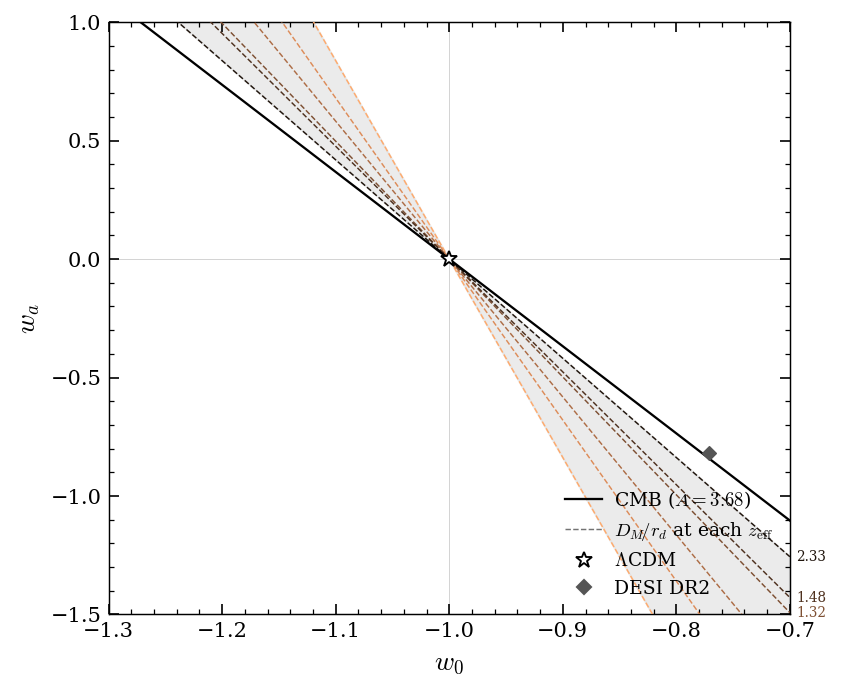

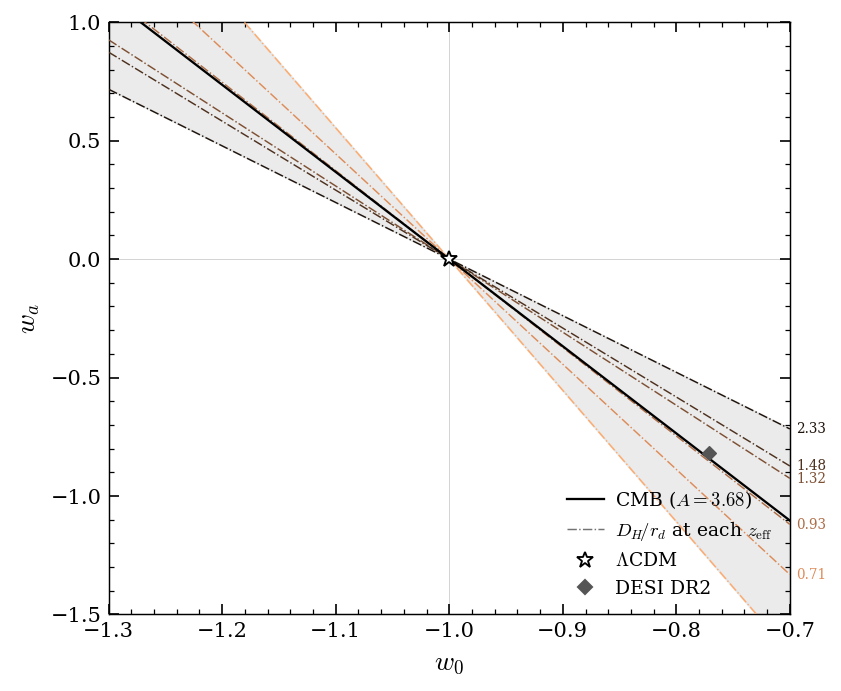

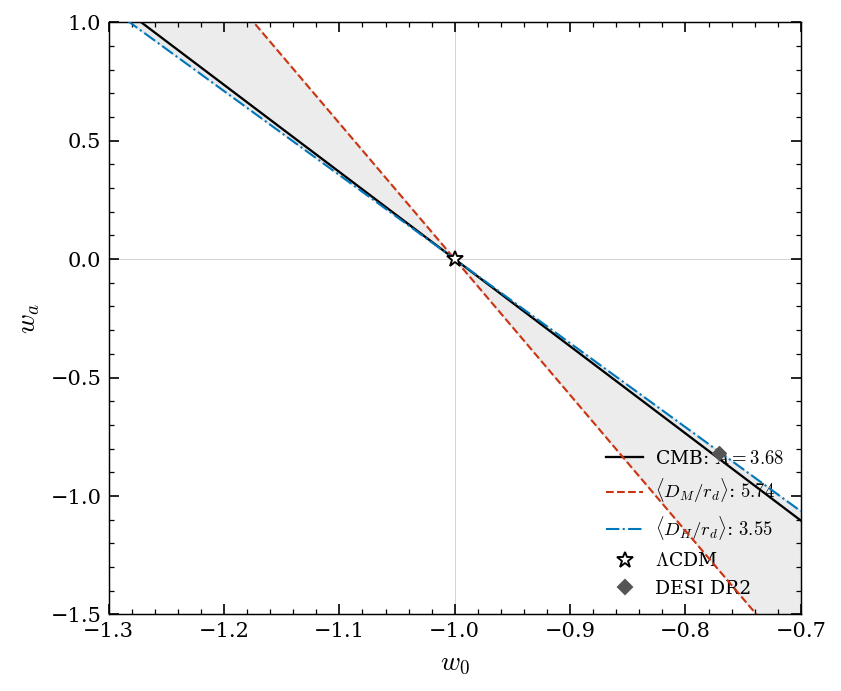

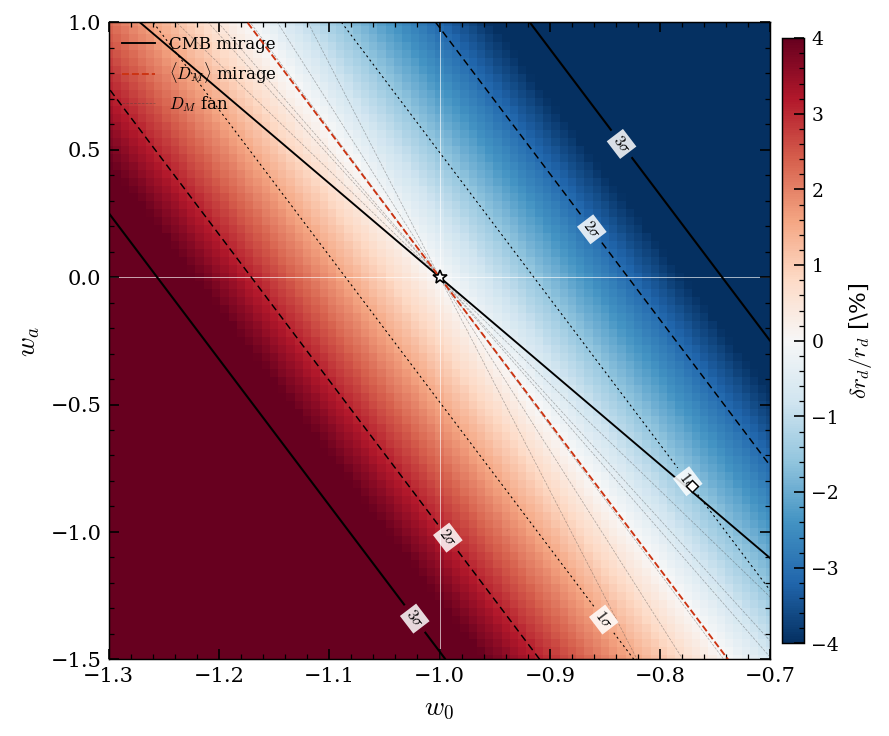

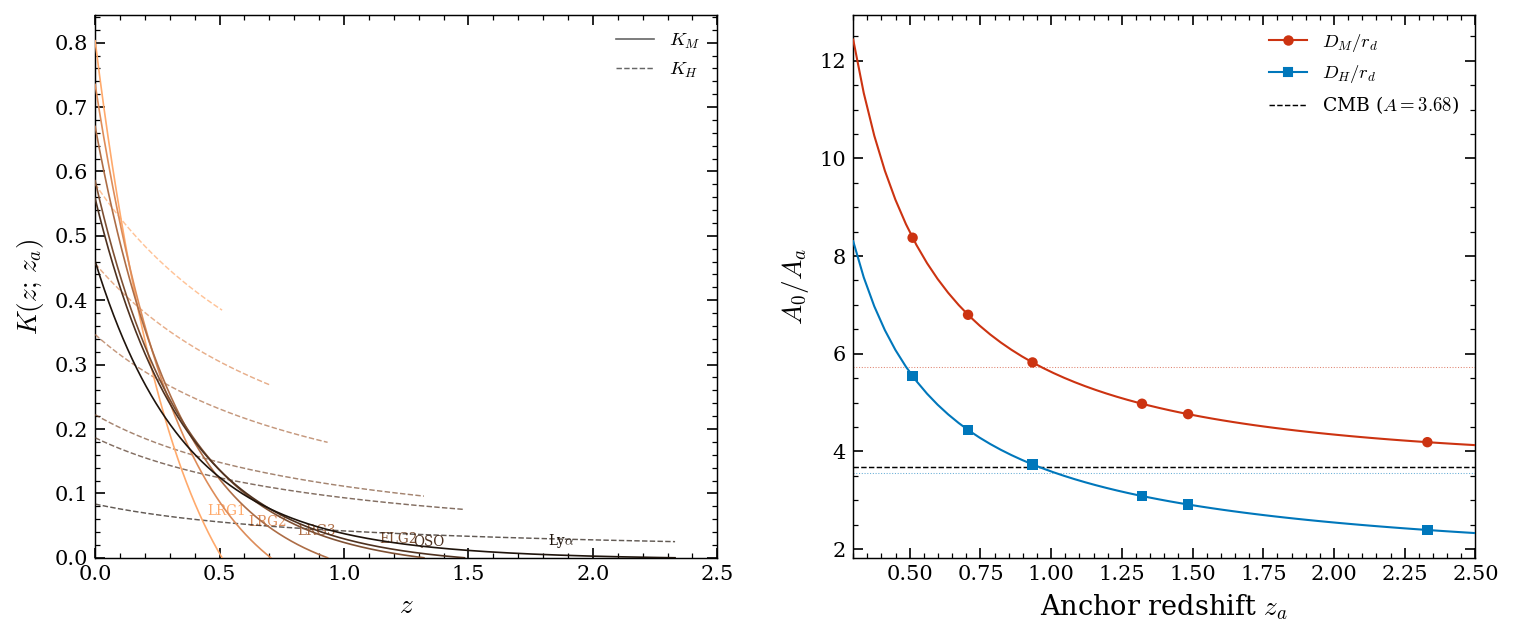


Done!


In [1]:
"""
BAO Robustness Analysis: Linder (2007) Mirage Effect WITH D_H
=====================================================

This code tests the "mirage of w=-1" using DESI DR2 BAO data.

TWO TYPES OF MIRAGE LINES:
1. CMB-anchored (Linder's original): Models matching d_lss to ΛCDM
2. BAO-anchored (your addition): Models matching D_M/r_d at each z_eff

"""

import numpy as np
import numpy.linalg as la
from dataclasses import dataclass
from typing import Tuple, Dict, List
import os

import matplotlib.pyplot as plt
from scipy.integrate import simpson, cumulative_trapezoid

import camb

# =============================================================================
# CONSTANTS
# =============================================================================

C_LIGHT = 299792.458  # km/s

# Sound horizon scaling coefficients
ALPHA_M = -0.25351  
ALPHA_B = -0.12807  

# Non-CMB prior on Ω_m (asymmetric)
om_m_CENTRAL = 0.1482
om_m_SIGMA = 0.009




# =============================================================================
# DESI DR2 DATA
# =============================================================================

DESI_TABLE_IV = [
    # (tracer, z_eff, DV, σ_DV, DM, σ_DM, DH, σ_DH, r_MH)
    ("BGS",       0.295,  7.942, 0.075,  np.nan, np.nan, np.nan, np.nan, np.nan),
    ("LRG1",      0.510, 12.720, 0.099, 13.588, 0.167, 21.863, 0.425, -0.459),
    ("LRG2",      0.706, 16.050, 0.110, 17.351, 0.177, 19.455, 0.330, -0.404),
    ("LRG3+ELG1", 0.934, 19.721, 0.091, 21.576, 0.152, 17.641, 0.193, -0.416),
    ("ELG2",      1.321, 24.252, 0.174, 27.601, 0.318, 14.176, 0.221, -0.434),
    ("QSO",       1.484, 26.055, 0.398, 30.512, 0.760, 12.817, 0.516, -0.500),
    ("Lya",       2.330, 31.267, 0.256, 38.988, 0.531,  8.632, 0.101, -0.431),
]


@dataclass
class BaoData:
    """Container for BAO measurements and covariance."""
    z: np.ndarray
    d: np.ndarray
    C: np.ndarray
    labels: list


def build_desi_dataset() -> BaoData:
    """Build DESI DR2 BAO dataset with block-diagonal covariance."""
    labels, d_list, blocks = [], [], []

    for tracer, z, DV, sDV, DM, sDM, DH, sDH, rMH in DESI_TABLE_IV:
        if tracer == "BGS":
            # Isotropic measurement only
            d_list.append(DV)
            labels.append(f"{tracer}: DV/rd @ z={z}")
            blocks.append(np.array([[sDV**2]]))
        else:
            # Anisotropic: DM and DH with correlation
            d_list.extend([DM, DH])
            labels.extend([f"{tracer}: DM/rd @ z={z}", f"{tracer}: DH/rd @ z={z}"])
            blocks.append(np.array([
                [sDM**2, rMH * sDM * sDH],
                [rMH * sDM * sDH, sDH**2]
            ]))

    # Assemble block-diagonal covariance
    dim = sum(b.shape[0] for b in blocks)
    C = np.zeros((dim, dim))
    idx = 0
    for block in blocks:
        n = block.shape[0]
        C[idx:idx+n, idx:idx+n] = block
        idx += n

    z_aniso = np.array([row[1] for row in DESI_TABLE_IV if row[0] != "BGS"])
    return BaoData(z=z_aniso, d=np.array(d_list), C=C, labels=labels)


def extract_DM_only(data: BaoData): # For our DM anchor
  
    idx_dm = np.array([i for i, lab in enumerate(data.labels) if "DM/rd" in lab]) # find indexes of DM/rd data
    d_dm = data.d[idx_dm] # new data vector
    C_dm = data.C[np.ix_(idx_dm, idx_dm)] # new covariance matrix
    z_dm = np.array([float(lab.split("z=")[-1]) for lab in np.array(data.labels)[idx_dm]]) # finding z values for our DM/rd data
    labels_dm = [data.labels[i] for i in idx_dm] # new data labels
    return z_dm, d_dm, C_dm, labels_dm, idx_dm

def extract_DH_only(data: BaoData): # For our DH anchor

    idx_dh= np.array([i for i, lab in enumerate(data.labels) if "DH/rd" in lab]) # find indexes of DM/rd data
    d_dh = data.d[idx_dh] # new data vector
    C_dh = data.C[np.ix_(idx_dh, idx_dh)] # new covariance matrix
    z_dh = np.array([float(lab.split("z=")[-1]) for lab in np.array(data.labels)[idx_dh]]) # finding z values for our DM/rd data
    labels_dh = [data.labels[i] for i in idx_dh] # new data labels
    return z_dh, d_dh, C_dh, labels_dh, idx_dh
    


# =============================================================================
# FIDUCIAL COSMOLOGY
# =============================================================================

class FiducialCosmology: # pre computing quantities on a grid to avoid repeated camb calls (my laptop is quite fragile)
    
    def __init__(self, H0=67.4, ombh2=0.02237, omch2=0.1200, mnu=0.06, omk=0.0): # our fiducial cosmology params
        self.H0 = H0
        self.ombh2 = ombh2
        self.omch2 = omch2
        
        # Set up CAMB
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=mnu, omk=omk, tau=0.054)
        pars.set_dark_energy(w=-1.0)
        pars.InitPower.set_params(As=2.1e-9, ns=0.965)
        pars.WantTransfer = True
        
        self._results = camb.get_results(pars)
        
        # Pre-compute on fine grid
        self._z_grid = np.linspace(0, 3.5, 5000) # grid from z=0-3.5 to encaplsulate BAO data range, 5000 points
        self._E_grid = np.array([self._results.hubble_parameter(z) / H0 # calculating a grid of E(z) values 
                                  for z in self._z_grid])
        self._OmDE_grid = np.array([self._results.get_Omega("de", z) # calculating a grid of Omega_DE(z) values
                                     for z in self._z_grid])
    
    def E(self, z: np.ndarray) -> np.ndarray:
        
        return np.interp(z, self._z_grid, self._E_grid) # interpolating values on our E(z) grid for general z (quicker than camb)
    
    def Omega_DE(self, z: np.ndarray) -> np.ndarray:
       
        return np.interp(z, self._z_grid, self._OmDE_grid) # interpolating our Omega_DE(z) values from grid
    
    def chi_dimless(self, z_a: float, n_points: int = 2000) -> float:
        
        z = np.linspace(0, z_a, n_points)
        E_z = self.E(z)
        return simpson(1.0 / E_z, x=z)


# Initialize fiducial cosmology (global)
print("Initializing fiducial ΛCDM cosmology with CAMB...")
FIDUCIAL = FiducialCosmology()
print("Done.\n")


# =============================================================================
# BAO DM KERNEL AND MOMENTS 
# =============================================================================

def BAO_DM_distance_kernel(z_a: float, n_points: int = 2000) -> Tuple[np.ndarray, np.ndarray]:
    
    # Redshift grid from 0 to z_a
    z = np.linspace(0.0, z_a, n_points)
    
    # Get fiducial quantities
    E_z = FIDUCIAL.E(z)
    OmDE_z = FIDUCIAL.Omega_DE(z)
    
    # Integrand for inner integral: Ω_DE(z) / E(z)
    f = OmDE_z / E_z
    
    # Cumulative integral F(z) = ∫₀^z dz' [Ω_DE/E] - gridwise
    F = cumulative_trapezoid(f, z, initial=0.0)
    
    # Inner integral: I(z) = F(z_a) - F(z) = ∫_z^{z_a} dz' [Ω_DE/E]
    I = F[-1] - F
    
    # CRITICAL: Use DIMENSIONLESS χ̃, not dimensional χ!
    # χ̃(z_a) = ∫₀^{z_a} dz/E(z)  [in units of c/H₀]
    chi_tilde_a = simpson(1.0 / E_z, x=z)
    
    # Prefactor: (3/2) · [1/(1+z)] · [1/χ̃(z_a)]
    prefactor = 1.5 / (1.0 + z) / chi_tilde_a
    
    # Full kernel
    K = prefactor * I
    
    return z, K


def compute_DM_A0_Aa(z_a: float, n_points: int = 2000) -> Tuple[float, float]:
    
    # Get kernel
    z, K = BAO_DM_distance_kernel(z_a, n_points)
    
    # CPL basis function g(z) = z/(1+z)
    g_z = z / (1.0 + z)
    
    # Integrate to get moments
    A0 = simpson(K, x=z)           # ∫ K dz
    Aa = simpson(K * g_z, x=z)     # ∫ K·g(z) dz
    
    return A0, Aa


def compute_all_DM_moments(z_anchors: np.ndarray, n_points: int = 2000) -> Tuple[np.ndarray, np.ndarray]:
    
    A0_list, Aa_list = [], []
    for z_a in z_anchors:
        a0, aa = compute_DM_A0_Aa(z_a, n_points)
        A0_list.append(a0)
        Aa_list.append(aa)
    return np.array(A0_list), np.array(Aa_list)


# =============================================================================
# BAO DM MIRAGE LINE
# =============================================================================

def BAO_DM_mirage_line(z_a: float, w0_array: np.ndarray, n_points: int = 2000) -> np.ndarray:
    
    A0, Aa = compute_DM_A0_Aa(z_a, n_points)
    
    delta_w0 = w0_array + 1.0
    
    wa_array = -(A0 / Aa) * delta_w0
    
    return wa_array


def combined_DM_BAO_mirage_line(z_anchors: np.ndarray, C_dm: np.ndarray, 
                             w0_array: np.ndarray, n_points: int = 2000) -> np.ndarray:
    """
    Compute combined BAO mirage line using covariance-weighted average.
    
    When multiple redshifts are measured with covariance C, the effective
    mirage line uses weighted moments.
    
    """
    A0, Aa = compute_all_DM_moments(z_anchors, n_points)
    
    # Inverse covariance weighting
    invC = la.inv(C_dm)
    
    # Weighted average of A₀/Aₐ ratio
    weights = np.diag(invC)
    weights /= weights.sum()
    
    A0_eff = np.sum(weights * A0)
    Aa_eff = np.sum(weights * Aa)
    
    delta_w0 = w0_array + 1.0
    wa_array = -(A0_eff / Aa_eff) * delta_w0
    
    return wa_array

# =============================================================================
# BAO DH KERNEL AND MOMENTS - NO KERNELS
# =============================================================================

def compute_DH_A0_Aa(z_a: float, n_points: int = 2000) -> Tuple[float, float]:
    
    z = np.linspace(0.0, z_a, n_points)          # ← was missing
    
    OmDE_za = FIDUCIAL.Omega_DE(z_a)             # ← was missing
    
    # K_H(z'; z_a) = (3/2) · Ω_DE(z_a) / (1+z')
    K_H = 1.5 * OmDE_za / (1.0 + z)
    
    g_z = z / (1.0 + z)
    
    A0 = simpson(K_H, x=z)
    Aa = simpson(K_H * g_z, x=z)
    
    return A0, Aa

def compute_all_DH_moments(z_anchors: np.ndarray, n_points: int = 2000) -> Tuple[np.ndarray, np.ndarray]:
    
    A0_list, Aa_list = [], []
    for z_a in z_anchors:
        a0, aa = compute_DH_A0_Aa(z_a, n_points)
        A0_list.append(a0)
        Aa_list.append(aa)
    return np.array(A0_list), np.array(Aa_list)

def BAO_DH_distance_kernel(z_a, n_points=2000):
    
    z = np.linspace(0.0, z_a, n_points)
    OmDE_za = FIDUCIAL.Omega_DE(z_a)
    K_H = 1.5 * OmDE_za / (1.0 + z)
    return z, K_H
# =============================================================================
# BAO DH MIRAGE LINE
# =============================================================================

def BAO_DH_mirage_line(z_a: float, w0_array: np.ndarray, n_points: int = 2000) -> np.ndarray:
    
    A0, Aa = compute_DH_A0_Aa(z_a, n_points)
    
    # δw₀ = w₀ - (-1) = w₀ + 1
    delta_w0 = w0_array + 1.0
    
    wa_array = -(A0 / Aa) * delta_w0
    
    return wa_array


def combined_DH_BAO_mirage_line(z_anchors: np.ndarray, C_dh: np.ndarray,   # ← renamed parameter
                             w0_array: np.ndarray, n_points: int = 2000) -> np.ndarray:
    A0, Aa = compute_all_DH_moments(z_anchors, n_points)
    invC = la.inv(C_dh)        
    
    # Weighted average of A₀/Aₐ ratio
    weights = np.diag(invC)
    weights /= weights.sum()
    
    A0_eff = np.sum(weights * A0)
    Aa_eff = np.sum(weights * Aa)
    
    delta_w0 = w0_array + 1.0
    wa_array = -(A0_eff / Aa_eff) * delta_w0
    
    return wa_array


# =============================================================================
# CMB MIRAGE LINE (Linder 2007)
# =============================================================================

def CMB_mirage_coefficient(Omega_m: float = 0.234, z_lss: float = 1089.0, 
                           n_points: int = 10000) -> float:
    
    Y = 1 + z_lss
    y = np.linspace(1.0, Y, n_points)
    
    denom = (Omega_m * y**3 + 1 - Omega_m)**(3/2)
    
    num_integrand = np.log(y) / denom
    den_integrand = (np.log(y) + 1/y - 1) / denom
    
    num = simpson(num_integrand, x=y)
    den = simpson(den_integrand, x=y)
    
    A = num / den
    return A


def CMB_mirage_line(w0_array, Omega_m=0.234):
    A = CMB_mirage_coefficient(Omega_m)
    return -A * (w0_array + 1.0)


# =============================================================================
# ROBUSTNESS ANALYSIS
# =============================================================================

def required_delta_ln_rd_fixed(z_dm, d_dm, C_dm, dw0, dwa, A0, Aa):
    """
    Find δ ln r_d that preserves D_M/r_d given CPL perturbation.
    
    """
    delta_lnDM = -(A0 * dw0 + Aa * dwa)
    
    # Convert to fractional covariance
    D_M_outer = np.outer(d_dm, d_dm)
    C_ln = C_dm / D_M_outer
    invC_ln = la.inv(C_ln)
    
    ones = np.ones_like(delta_lnDM)
    delta_ln_rd = (ones @ invC_ln @ delta_lnDM) / (ones @ invC_ln @ ones)
    
    return delta_ln_rd, delta_lnDM

def delta_ln_omm_from_rd(delta_ln_rd):
    
    return delta_ln_rd / ALPHA_M

from scipy.stats import chi2 as chi2_dist


def required_delta_ln_rd_with_chi2(z_dm, d_dm, C_dm, dw0, dwa, A0, Aa):
    """
    Find δ ln r_d that preserves D_M/r_d, AND compute χ² of the fit.
    
    """
    
    # Required δ ln D_M at each redshift from perturbation theory
    delta_lnDM = -(A0 * dw0 + Aa * dwa)
    
    
    D_M_outer = np.outer(d_dm, d_dm)  # D_M[i] * D_M[j] matrix
    C_ln = C_dm / D_M_outer  # Covariance of ln(D_M)
    
    # Now both C_ln and delta_lnDM are in the same (fractional) units
    invC_ln = la.inv(C_ln)
    
    # Number of data points
    N = len(z_dm)
    
    # Best-fit δ ln r_d (weighted least squares)
    ones = np.ones(N)
    delta_ln_rd = (ones @ invC_ln @ delta_lnDM) / (ones @ invC_ln @ ones)
    
    # Residuals: how well does a single δ ln r_d match all redshifts?
    residuals = delta_lnDM - delta_ln_rd * ones
    
    # χ² of the fit (now with correct units!)
    chi2 = residuals @ invC_ln @ residuals
    
    # Degrees of freedom: N data points - 1 fitted parameter
    ndof = N - 1
    
    # p-value: probability of getting χ² this large or larger by chance
    pvalue = 1 - chi2_dist.cdf(chi2, ndof)
    
    return delta_ln_rd, delta_lnDM, chi2, ndof, pvalue


def interpret_chi2(chi2, ndof, pvalue):
    
    chi2_per_dof = chi2 / ndof
    
    print(f"\n  χ² of r_d fit:")
    print(f"    χ² = {chi2:.2f}")
    print(f"    N_dof = {ndof}")
    print(f"    χ²/N_dof = {chi2_per_dof:.2f}")
    print(f"    p-value = {pvalue:.3f} ({100*pvalue:.1f}%)")
    
    if pvalue > 0.10:
        print(f"    → GOOD FIT: A single r_d shift can match all redshifts")
        print(f"       The mirage is internally self-consistent.")
    elif pvalue > 0.01:
        print(f"    → MARGINAL FIT: Some tension between redshifts")
        print(f"       The mirage works but not perfectly.")
    else:
        print(f"    → POOR FIT: No single r_d shift works well")
        print(f"       The mirage fails INTERNALLY, even before checking ω_m prior!")
    
    return chi2_per_dof



def plausibility_score(delta_ln_omm):
    """
    Compute tension T = |δ ln ω_m| / σ(ln ω_m).
    
    """
    
    delta_ln_omm = np.atleast_1d(delta_ln_omm)
    
    # Get propagated uncertainties
    delta_ln_om_prior = om_m_SIGMA / om_m_CENTRAL
    
    
    # Use σ⁺ for positive shifts, σ⁻ for negative shifts
    T = np.abs((delta_ln_omm) / (delta_ln_om_prior))
    
    return T

def compute_robustness_maps(w0_range=(-1.3, -0.7), wa_range=(-1.5, 1.0),
                            n_grid=101, n_kernel_pts=2000):
    """Compute robustness maps over (w₀, wₐ) grid."""
    bao = build_desi_dataset()
    z_dm, d_dm, C_dm, labels_dm, _ = extract_DM_only(bao)
    
    print(f"Computing kernel moments for z = {z_dm}...")
    A0, Aa = compute_all_DM_moments(z_dm, n_kernel_pts)
    
    print(f"Kernel moments:")
    for z, a0, aa in zip(z_dm, A0, Aa):
        print(f"  z={z:.3f}: A₀={a0:.4f}, Aₐ={aa:.4f}, A₀/Aₐ={a0/aa:.3f}")
    
    w0_grid = np.linspace(w0_range[0], w0_range[1], n_grid)
    wa_grid = np.linspace(wa_range[0], wa_range[1], n_grid)
    
    delta_ln_rd_map = np.zeros((n_grid, n_grid))
    delta_ln_omm_map = np.zeros((n_grid, n_grid))
    T_map = np.zeros((n_grid, n_grid))
    
    print(f"Computing {n_grid}×{n_grid} robustness grid...")
    for i, wa in enumerate(wa_grid):
        for j, w0 in enumerate(w0_grid):
            dw0, dwa = w0 + 1.0, wa
            dlnrd, _ = required_delta_ln_rd_fixed(z_dm, d_dm, C_dm, dw0, dwa, A0, Aa)
            dlnomm = delta_ln_omm_from_rd(dlnrd)
            T = plausibility_score(dlnomm)
            
            delta_ln_rd_map[i, j] = dlnrd
            delta_ln_omm_map[i, j] = dlnomm
            T_map[i, j] = T[0] if hasattr(T, '__len__') else T
    
    return {
        'w0_grid': w0_grid, 'wa_grid': wa_grid,
        'delta_ln_rd': delta_ln_rd_map,
        'delta_ln_omm': delta_ln_omm_map,
        'T_map': T_map,
        'z_dm': z_dm, 'A0': A0, 'Aa': Aa, 'C_dm': C_dm
    }

def verify_CMB_limit(z_lss=1089.0, n_points=80000):
    """
    Verify that the BAO D_M mirage slope A₀/Aₐ → A_cmb as z_a → z_lss.

    Builds a temporary extended cosmology grid to z = z_lss, computes
    the D_M kernel moments there, and compares to Linder's analytical
    CMB mirage coefficient.

    """

    # --- Extended fiducial cosmology grid ---
    # Use log-spaced grid at high z for efficiency: most of the
   

    z_lo = np.linspace(0, 5, 5000)                    # fine grid where kernel peaks
    z_hi = np.geomspace(5.01, z_lss, 15000)           # log-spaced to z_lss
    z_ext = np.concatenate([z_lo, z_hi])

    # Compute E(z) and Ω_DE(z) analytically for ΛCDM
    
    Om = FIDUCIAL.Om if hasattr(FIDUCIAL, 'Om') else \
         (FIDUCIAL.ombh2 + FIDUCIAL.omch2) / (FIDUCIAL.H0 / 100.0)**2
    ODE_0 = 1.0 - Om

    E_ext = np.sqrt(Om * (1 + z_ext)**3 + ODE_0)
    OmDE_ext = ODE_0 / E_ext**2

    # Compute D_M kernel moments at z_a = z_lss
    z = np.linspace(0, z_lss, n_points)

    # Interpolate E and Ω_DE from extended grid
    E_z = np.interp(z, z_ext, E_ext)
    OmDE_z = np.interp(z, z_ext, OmDE_ext)

    # Inner integral 
    f = OmDE_z / E_z
    F = cumulative_trapezoid(f, z, initial=0.0)
    I = F[-1] - F

    # Dimensionless comoving distance
    chi = simpson(1.0 / E_z, x=z)

    # Kernel
    K = 1.5 / (1.0 + z) / chi * I

    # Moments
    g = z / (1.0 + z)
    A0 = simpson(K, x=z)
    Aa = simpson(K * g, x=z)
    slope_BAO = A0 / Aa

    # Linder analytical
    A_cmb = CMB_mirage_coefficient(Omega_m=Om)

    frac_err = abs(slope_BAO - A_cmb) / A_cmb

    
    # Show how A₀/Aₐ evolves as z_a increases from DESI range toward z_lss
    test_redshifts = [0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 200.0, 500.0, 1089.0]
    conv_slopes = []

    for z_a in test_redshifts:
        zz = np.linspace(0, z_a, max(10000, int(n_points * z_a / z_lss)))
        Ez = np.interp(zz, z_ext, E_ext)
        ODz = np.interp(zz, z_ext, OmDE_ext)

        ff = ODz / Ez
        FF = cumulative_trapezoid(ff, zz, initial=0.0)
        II = FF[-1] - FF
        cc = simpson(1.0 / Ez, x=zz)
        KK = 1.5 / (1.0 + zz) / cc * II
        gg = zz / (1.0 + zz)

        a0 = simpson(KK, x=zz)
        aa = simpson(KK * gg, x=zz)
        conv_slopes.append(a0 / aa)

    return {
        'A_cmb': A_cmb,
        'slope_BAO': slope_BAO,
        'A0': A0,
        'Aa': Aa,
        'frac_error': frac_err,
        'convergence_z': test_redshifts,
        'convergence_slopes': conv_slopes,
    }



# =============================================================================
# PLOTTING 
# =============================================================================


from matplotlib.lines import Line2D


def plot_publication_figures(results, output_dir=None):
   

    if output_dir is None:
        output_dir = os.getcwd()
    os.makedirs(output_dir, exist_ok=True)

    # ── RC params ─────────────────────────────────────────────────────────
    plt.rcParams.update({
        'font.family':         'serif',
        'font.serif':          ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
        'mathtext.fontset':    'cm',
        'text.usetex':         False,
        'font.size':           11,
        'axes.labelsize':      13,
        'legend.fontsize':     9,
        'xtick.labelsize':     10,
        'ytick.labelsize':     10,
        'xtick.direction':     'in',
        'ytick.direction':     'in',
        'xtick.top':           True,
        'ytick.right':         True,
        'xtick.minor.visible': True,
        'ytick.minor.visible': True,
        'xtick.major.size':    5,
        'ytick.major.size':    5,
        'xtick.minor.size':    2.5,
        'ytick.minor.size':    2.5,
        'axes.linewidth':      0.7,
        'figure.dpi':          150,
        'savefig.dpi':         300,
        'savefig.bbox':        'tight',
        'savefig.pad_inches':  0.03,
    })

    # ── Unpack ────────────────────────────────────────────────────────────
    w0g    = results['w0_grid']
    wag    = results['wa_grid']
    z_dm   = results['z_dm']
    A0_M   = results['A0'];  Aa_M = results['Aa']
    T_map  = results['T_map']
    C_dm   = results['C_dm']; d_dm = results['d_dm']
    z_dh   = results['z_dh']; d_dh = results['d_dh']; C_dh = results['C_dh']

    A0_H, Aa_H = compute_all_DH_moments(z_dm)
    om_camb = (FIDUCIAL.ombh2 + FIDUCIAL.omch2) / (FIDUCIAL.H0 / 100.0)**2
    A_cmb = CMB_mirage_coefficient(Omega_m=om_camb)

    w0_line = np.linspace(-1.3, -0.7, 300)
    wa_cmb  = -A_cmb * (w0_line + 1.0)

    w0_D, wa_D = -0.771, -0.820   # DESI DR2 preferred (CMB-independent)

    # ── Colours ───────────────────────────────────────────────────────────
    n_z = len(z_dm)
    _cmap = plt.cm.copper_r
    z_colors = [_cmap(0.15 + 0.75 * i / (n_z - 1)) for i in range(n_z)]

    cmb_col    = 'k'
    desi_col   = '#555555'
    dm_avg_col = '#CC3311'   # vermillion
    dh_avg_col = '#0077BB'   # blue

    # ── Helpers ───────────────────────────────────────────────────────────
    def _axes(ax):
        ax.set_xlabel(r'$w_0$')
        ax.set_ylabel(r'$w_a$')
        ax.set_xlim(-1.3, -0.7)
        ax.set_ylim(-1.5, 1.0)

    def _ref(ax):
        ax.axvline(-1, color='0.80', lw=0.4, zorder=0)
        ax.axhline(0,  color='0.80', lw=0.4, zorder=0)
        ax.plot(-1, 0, '*', ms=8, mfc='w', mec='k', mew=0.9, zorder=20)
        ax.plot(w0_D, wa_D, 'D', ms=4.5, mfc=desi_col, mec=desi_col,
                mew=0.6, zorder=20)

    def _save(fig, name):
        for ext in ('.pdf', '.png'):
            fig.savefig(os.path.join(output_dir, name + ext))
        print(f"  Saved: {name}.pdf / .png")

    # Pre-compute weighted-average slopes 
    invC_dm_f = la.inv(C_dm / np.outer(d_dm, d_dm))
    wt_dm = np.diag(invC_dm_f).copy(); wt_dm /= wt_dm.sum()
    slope_DM = np.sum(wt_dm * A0_M) / np.sum(wt_dm * Aa_M)

    invC_dh_f = la.inv(C_dh / np.outer(d_dh, d_dh))
    wt_dh = np.diag(invC_dh_f).copy(); wt_dh /= wt_dh.sum()
    slope_DH = np.sum(wt_dh * A0_H) / np.sum(wt_dh * Aa_H)

    wa_DM_avg = -slope_DM * (w0_line + 1)
    wa_DH_avg = -slope_DH * (w0_line + 1)

    # =====================================================================
    # FIG 1 — D_M / r_d  mirage fan
    # =====================================================================
    fig1, ax = plt.subplots(figsize=(5.5, 4.5))

    ax.plot(w0_line, wa_cmb, 'k-', lw=1.1, zorder=10)

    wa_DM_all = []
    for i, z_a in enumerate(z_dm):
        s = A0_M[i] / Aa_M[i]
        wa_bao = -s * (w0_line + 1)
        wa_DM_all.append(wa_bao)
        ax.plot(w0_line, wa_bao, color=z_colors[i], ls='--', lw=0.7, zorder=5)

    wa_DM_arr = np.array(wa_DM_all)
    ax.fill_between(w0_line, wa_DM_arr.min(0), wa_DM_arr.max(0),
                    color='0.85', alpha=0.5, zorder=1)

    _ref(ax); _axes(ax)

    leg1 = [
        Line2D([0],[0], color='k', ls='-', lw=1.1,
               label=r'CMB ($A={:.2f}$)'.format(A_cmb)),
        Line2D([0],[0], color='0.45', ls='--', lw=0.7,
               label=r'$D_M\!/r_d$ at each $z_{\rm eff}$'),
        Line2D([0],[0], marker='*', color='w', mec='k', mew=0.9, ms=8,
               ls='None', label=r'$\Lambda$CDM'),
        Line2D([0],[0], marker='D', color='w', mec=desi_col, mfc=desi_col,
               ms=4.5, ls='None', label='DESI DR2'),
    ]
    ax.legend(handles=leg1, loc='lower right', frameon=False,
              handlelength=2.0, borderpad=0.4, handletextpad=0.6)

    for i, z_a in enumerate(z_dm):
        s = A0_M[i] / Aa_M[i]
        wa_end = -s * (-0.7 + 1)
        if -1.5 < wa_end < 1.0:
            ax.annotate(f'{z_a:.2f}', xy=(-0.70, wa_end),
                        fontsize=6.5, color=z_colors[i], ha='left', va='center',
                        xytext=(3, 0), textcoords='offset points')

    fig1.tight_layout(pad=0.3)
    _save(fig1, 'fig1_DM_mirage_fan')

    # =====================================================================
    # FIG 2 — D_H / r_d  mirage fan
    # =====================================================================
    fig2, ax = plt.subplots(figsize=(5.5, 4.5))

    ax.plot(w0_line, wa_cmb, 'k-', lw=1.1, zorder=10)

    wa_DH_all = []
    for i, z_a in enumerate(z_dm):
        s = A0_H[i] / Aa_H[i]
        wa_bao = -s * (w0_line + 1)
        wa_DH_all.append(wa_bao)
        ax.plot(w0_line, wa_bao, color=z_colors[i], ls='-.', lw=0.7, zorder=5)

    wa_DH_arr = np.array(wa_DH_all)
    ax.fill_between(w0_line, wa_DH_arr.min(0), wa_DH_arr.max(0),
                    color='0.85', alpha=0.5, zorder=1)

    _ref(ax); _axes(ax)

    leg2 = [
        Line2D([0],[0], color='k', ls='-', lw=1.1,
               label=r'CMB ($A={:.2f}$)'.format(A_cmb)),
        Line2D([0],[0], color='0.45', ls='-.', lw=0.7,
               label=r'$D_H\!/r_d$ at each $z_{\rm eff}$'),
        Line2D([0],[0], marker='*', color='w', mec='k', mew=0.9, ms=8,
               ls='None', label=r'$\Lambda$CDM'),
        Line2D([0],[0], marker='D', color='w', mec=desi_col, mfc=desi_col,
               ms=4.5, ls='None', label='DESI DR2'),
    ]
    ax.legend(handles=leg2, loc='lower right', frameon=False,
              handlelength=2.0, borderpad=0.4, handletextpad=0.6)

    for i, z_a in enumerate(z_dm):
        s = A0_H[i] / Aa_H[i]
        wa_end = -s * (-0.7 + 1)
        if -1.5 < wa_end < 1.0:
            ax.annotate(f'{z_a:.2f}', xy=(-0.70, wa_end),
                        fontsize=6.5, color=z_colors[i], ha='left', va='center',
                        xytext=(3, 0), textcoords='offset points')

    fig2.tight_layout(pad=0.3)
    _save(fig2, 'fig2_DH_mirage_fan')

    # =====================================================================
    # FIG 3 — Weighted-average D_M + D_H + CMB
    # =====================================================================
    fig3, ax = plt.subplots(figsize=(5.5, 4.5))

    ax.plot(w0_line, wa_cmb, 'k-',  lw=1.1, zorder=10)
    ax.plot(w0_line, wa_DM_avg, color=dm_avg_col, ls='--', lw=1.0, zorder=10)
    ax.plot(w0_line, wa_DH_avg, color=dh_avg_col, ls='-.', lw=1.0, zorder=10)

    ax.fill_between(w0_line, wa_DM_avg, wa_DH_avg,
                    color='0.88', alpha=0.6, zorder=1)
    ax.fill_between(w0_line, wa_cmb, wa_DH_avg,
                    color=dh_avg_col, alpha=0.04, zorder=0)

    _ref(ax); _axes(ax)

    leg3 = [
        Line2D([0],[0], color='k', ls='-', lw=1.1,
               label=r'CMB: $A = {:.2f}$'.format(A_cmb)),
        Line2D([0],[0], color=dm_avg_col, ls='--', lw=1.0,
               label=r'$\langle D_M/r_d \rangle$: ${:.2f}$'.format(slope_DM)),
        Line2D([0],[0], color=dh_avg_col, ls='-.', lw=1.0,
               label=r'$\langle D_H/r_d \rangle$: ${:.2f}$'.format(slope_DH)),
        Line2D([0],[0], marker='*', color='w', mec='k', mew=0.9, ms=8,
               ls='None', label=r'$\Lambda$CDM'),
        Line2D([0],[0], marker='D', color='w', mec=desi_col, mfc=desi_col,
               ms=4.5, ls='None', label='DESI DR2'),
    ]
    ax.legend(handles=leg3, loc='lower right', frameon=False,
              handlelength=2.0, borderpad=0.4, handletextpad=0.6)

    fig3.tight_layout(pad=0.3)
    _save(fig3, 'fig3_average_slopes')

    # =====================================================================
    # FIG 4 — Robustness heatmap
    # =====================================================================
    fig4, ax = plt.subplots(figsize=(6.0, 4.8))

    rd_pct = 100.0 * results['delta_ln_rd']

    im = ax.pcolormesh(w0g, wag, rd_pct, cmap='RdBu_r',
                       vmin=-4, vmax=4, shading='nearest',
                       rasterized=True, zorder=0)
    cb = fig4.colorbar(im, ax=ax, pad=0.015, aspect=28, shrink=0.95)
    cb.set_label(r'$\delta r_d / r_d$ [\%]', fontsize=11)
    cb.ax.tick_params(labelsize=9)

    lvls = [1, 2, 3]
    sty  = {1: (0.5, (0, (2, 3))),    # dotted
            2: (0.7, (0, (5, 3))),     # dashed
            3: (1.0, '-')}             # solid
    cs = ax.contour(w0g, wag, T_map, levels=lvls, colors='k',
                    linewidths=[sty[l][0] for l in lvls],
                    linestyles=[sty[l][1] for l in lvls],
                    zorder=15)
    fmt = {1: r'$1\sigma$', 2: r'$2\sigma$', 3: r'$3\sigma$'}
    cl = ax.clabel(cs, inline=True, fontsize=7.5, fmt=fmt)
    for c in cl:
        c.set_bbox(dict(fc='w', ec='none', pad=0.8, alpha=0.85))

    ax.plot(w0_line, wa_cmb, 'k-', lw=0.9, zorder=12)

    for i in range(n_z):
        s = A0_M[i] / Aa_M[i]
        ax.plot(w0_line, -s*(w0_line+1), color='0.25', ls='--', lw=0.35,
                alpha=0.40, zorder=8)

    ax.plot(w0_line, wa_DM_avg, color=dm_avg_col, ls='--', lw=0.9, zorder=12)

    ax.axvline(-1, color='w', lw=0.3, zorder=1)
    ax.axhline(0,  color='w', lw=0.3, zorder=1)
    ax.plot(-1, 0, '*', ms=7, mfc='w', mec='k', mew=0.8, zorder=20)
    ax.plot(w0_D, wa_D, 'D', ms=4, mfc='w', mec='k', mew=0.7, zorder=20)

    _axes(ax)

    leg4 = [
        Line2D([0],[0], color='k', ls='-', lw=0.9, label='CMB mirage'),
        Line2D([0],[0], color=dm_avg_col, ls='--', lw=0.9,
               label=r'$\langle D_M \rangle$ mirage'),
        Line2D([0],[0], color='0.25', ls='--', lw=0.35, alpha=0.5,
               label=r'$D_M$ fan'),
    ]
    ax.legend(handles=leg4, loc='upper left', frameon=False,
              fontsize=8, handlelength=2.0, borderpad=0.3)

    fig4.tight_layout(pad=0.3)
    _save(fig4, 'fig4_robustness_heatmap')

    # =====================================================================
    # FIG 5 — Kernel analysis (two-panel)
    # =====================================================================
    fig5, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.2))

    # Tracer short labels for annotation
    _tracer_labels = ['LRG1', 'LRG2', 'LRG3', 'ELG2', 'QSO', r'Ly$\alpha$']

    # --- Left panel: kernels ---
    for i, z_a in enumerate(z_dm):
        z_grid, K_M = BAO_DM_distance_kernel(z_a)
        z_grid_H, K_H = BAO_DH_distance_kernel(z_a)

        axL.plot(z_grid, K_M, color=z_colors[i], ls='-', lw=0.8, zorder=5)
        axL.plot(z_grid_H, K_H, color=z_colors[i], ls='--', lw=0.7,
                 alpha=0.7, zorder=4)

    axL.set_xlabel(r'$z$')
    axL.set_ylabel(r'$K(z;\, z_a)$')
    axL.set_xlim(0, 2.5)
    axL.set_ylim(bottom=0)

    leg5L = [
        Line2D([0],[0], color='0.4', ls='-', lw=0.8, label=r'$K_M$'),
        Line2D([0],[0], color='0.4', ls='--', lw=0.7, label=r'$K_H$'),
    ]
    axL.legend(handles=leg5L, loc='upper right', frameon=False,
               handlelength=2.0, fontsize=9)

    # Annotate at the right end of each K_M curve (near z_a),
    # where the curves are well-separated and the label sits
    # naturally at the endpoint.
    for i, z_a in enumerate(z_dm):
        z_grid, K_M = BAO_DM_distance_kernel(z_a)
        # Find index ~90% of the way through the kernel support
        ann_idx = int(0.85 * len(z_grid))
        # Only annotate if the kernel value is still visible
        if K_M[ann_idx] > 0.005:
            axL.annotate(_tracer_labels[i],
                         xy=(z_grid[ann_idx], K_M[ann_idx]),
                         fontsize=6.5, color=z_colors[i],
                         ha='left', va='bottom',
                         xytext=(2, 2), textcoords='offset points')
        else:
            # For long-range kernels that are very flat at 85%,
            # annotate at the rightmost visible point
            vis = np.where(K_M > 0.005)[0]
            if len(vis) > 0:
                j = vis[-1]
                axL.annotate(_tracer_labels[i],
                             xy=(z_grid[j], K_M[j]),
                             fontsize=6.5, color=z_colors[i],
                             ha='left', va='bottom',
                             xytext=(2, 2), textcoords='offset points')

    # --- Right panel: slopes vs redshift ---
    z_cont = np.linspace(0.3, 2.5, 60)
    ratios_M, ratios_H = [], []
    for z_a in z_cont:
        a0m, aam = compute_DM_A0_Aa(z_a, n_points=1500)
        a0h, aah = compute_DH_A0_Aa(z_a, n_points=1500)
        ratios_M.append(a0m / aam)
        ratios_H.append(a0h / aah)

    axR.plot(z_cont, ratios_M, color=dm_avg_col, ls='-', lw=1.0, zorder=5)
    axR.plot(z_cont, ratios_H, color=dh_avg_col, ls='-', lw=1.0, zorder=5)
    axR.axhline(A_cmb, color='k', ls='--', lw=0.7, zorder=3)

    # Mark DESI z_eff points
    axR.scatter(z_dm, A0_M / Aa_M, s=25, c=dm_avg_col, marker='o',
                zorder=10, edgecolors='none')
    axR.scatter(z_dm, A0_H / Aa_H, s=25, c=dh_avg_col, marker='s',
                zorder=10, edgecolors='none')

    # Mark weighted averages as horizontal bands
    axR.axhline(slope_DM, color=dm_avg_col, ls=':', lw=0.5, alpha=0.6)
    axR.axhline(slope_DH, color=dh_avg_col, ls=':', lw=0.5, alpha=0.6)

    axR.set_xlabel(r'Anchor redshift $z_a$')
    axR.set_ylabel(r'$A_0 / A_a$')
    axR.set_xlim(0.3, 2.5)

    leg5R = [
        Line2D([0],[0], color=dm_avg_col, ls='-', lw=1.0,
               marker='o', ms=4, label=r'$D_M/r_d$'),
        Line2D([0],[0], color=dh_avg_col, ls='-', lw=1.0,
               marker='s', ms=4, label=r'$D_H/r_d$'),
        Line2D([0],[0], color='k', ls='--', lw=0.7,
               label=r'CMB ($A={:.2f}$)'.format(A_cmb)),
    ]
    axR.legend(handles=leg5R, loc='upper right', frameon=False,
               handlelength=2.0, fontsize=9)

    fig5.tight_layout(pad=0.5, w_pad=2.0)
    _save(fig5, 'fig5_kernel_analysis')

    # ── Reset rc ──────────────────────────────────────────────────────────
    plt.rcParams.update(plt.rcParamsDefault)

    return fig1, fig2, fig3, fig4, fig5


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("BAO ROBUSTNESS ANALYSIS: LINDER (2007) MIRAGE EFFECT")
    print("=" * 70)

    # CMB mirage coefficient
    om_camb = (FIDUCIAL.ombh2 + FIDUCIAL.omch2) / (FIDUCIAL.H0 / 100.0)**2
    A_cmb = CMB_mirage_coefficient(Omega_m=om_camb)
    a_w = 1 - 1 / A_cmb
    z_w = 1 / a_w - 1
    print(f"\nLinder CMB mirage:")
    print(f"  Coefficient A = {A_cmb:.3f}")
    print(f"  Crossover a_w = {a_w:.3f} (z_w = {z_w:.2f})")
    print(f"  CMB mirage line: wa = -{A_cmb:.2f} * (1 + w0)")

    # Build DESI dataset
    bao = build_desi_dataset()
    z_dm, d_dm, C_dm, labels_dm, _ = extract_DM_only(bao)
    z_dh, d_dh, C_dh, labels_dh, _ = extract_DH_only(bao)

    print(f"\nDESI DR2 D_M/r_d measurements:")
    for lab in labels_dm:
        print(f"  {lab}")

    print(f"\nDESI DR2 D_H/r_d measurements:")
    for lab in labels_dh:
        print(f"  {lab}")

    # BAO D_M mirage parameters
    print(f"\nBAO D_M mirage parameters:")
    A0, Aa = compute_all_DM_moments(z_dm)
    for z_a, a0, aa in zip(z_dm, A0, Aa):
        ratio = a0 / aa
        print(f"  z={z_a:.3f}: A0={a0:.4f}, Aa={aa:.4f}, slope=-{ratio:.3f}")
        print(f"           BAO DM mirage: wa = -{ratio:.2f} * (1 + w0)")


    # CMB limit verification
    print("\n" + "-" * 70)
    print("CMB LIMIT VERIFICATION: BAO D_M slope → Linder A at z_a = 1089")
    print("-" * 70)

    cmb_check = verify_CMB_limit()

    print(f"\n  Linder analytical A_cmb  = {cmb_check['A_cmb']:.6f}")
    print(f"  BAO kernel A₀/Aₐ(z=1089) = {cmb_check['slope_BAO']:.6f}")
    print(f"  A₀ = {cmb_check['A0']:.6f},  Aₐ = {cmb_check['Aa']:.6f}")
    print(f"  Fractional error = {cmb_check['frac_error']:.2e}"
          f"  ({cmb_check['frac_error']*100:.4f}%)")

    if cmb_check['frac_error'] < 0.001:
        print("  ✓ PASSED: BAO formalism recovers CMB mirage to < 0.1%")
    else:
        print("  ✗ Check extended grid or integration resolution")

    print(f"\n  Convergence of A₀/Aₐ with anchor redshift:")
    print(f"  {'z_a':>8s}  {'A₀/Aₐ':>10s}  {'Δ from A_cmb':>12s}")
    for z_a, slope in zip(cmb_check['convergence_z'],
                          cmb_check['convergence_slopes']):
        delta = slope - cmb_check['A_cmb']
        print(f"  {z_a:8.1f}  {slope:10.4f}  {delta:+12.4f}")

    # BAO D_H mirage parameters
    print(f"\nBAO D_H mirage parameters:")
    A0_H, Aa_H = compute_all_DH_moments(z_dm)
    for z_a, a0h, aah in zip(z_dm, A0_H, Aa_H):
        ratio_h = a0h / aah
        print(f"  z={z_a:.3f}: A0={a0h:.4f}, Aa={aah:.4f}, slope=-{ratio_h:.3f}")
        print(f"           BAO DH mirage: wa = -{ratio_h:.2f} * (1 + w0)")

    # Non-perturbative validation at DESI point
    print("\n" + "-" * 70)
    print("NON-PERTURBATIVE VALIDATION AT DESI POINT")
    print("-" * 70)

    dw0, dwa = 0.164, -0.586
    dlnrd, delta_lnDM, chi2, ndof, pvalue = required_delta_ln_rd_with_chi2(
        z_dm, d_dm, C_dm, dw0, dwa, A0, Aa
    )
    dlnomm = delta_ln_omm_from_rd(dlnrd)
    T = plausibility_score(dlnomm)

    print(f"\n  (w0, wa) = (-0.771, -0.82)")
    print(f"  Required dr_d/r_d  = {100*dlnrd:+.2f}%")
    print(f"  Required dom_m/om_m = {100*dlnomm:+.2f}%")
    print(f"  Tension T = {T[0]:.1f}sigma")

    chi2_per_dof = interpret_chi2(chi2, ndof, pvalue)

    if T[0] < 2:
        print("  -> MIRAGE OPERATES: Degeneracy is plausible!")
    elif T[0] < 3:
        print("  -> MARGINAL: Degeneracy is borderline.")
    else:
        print("  -> ROBUST: Required shift implausible, DE detection solid.")

    # Individual bin breakdown
    print(f"\n  Per-bin delta ln D_M:")
    for z_a, dlnDM_i, a0, aa in zip(z_dm, delta_lnDM, A0, Aa):
        slope_i = a0 / aa
        print(f"    z={z_a:.3f}: delta ln D_M = {dlnDM_i:+.5f}  "
              f"(requires delta ln r_d = {dlnDM_i:+.5f}, "
              f"slope = {slope_i:.2f})")

    print(f"\n  Weighted-average delta ln r_d = {dlnrd:+.5f}")
    print(f"  chi2 = {chi2:.2f} / {ndof} dof  (p = {pvalue:.3f})")

    # Weighted-average slopes
    print("\n" + "-" * 70)
    print("COVARIANCE-WEIGHTED AVERAGE MIRAGE SLOPES")
    print("-" * 70)

    invC_dm_frac = la.inv(C_dm / np.outer(d_dm, d_dm))
    w_dm = np.diag(invC_dm_frac).copy(); w_dm /= w_dm.sum()
    slope_DM_avg = np.sum(w_dm * A0) / np.sum(w_dm * Aa)

    invC_dh_frac = la.inv(C_dh / np.outer(d_dh, d_dh))
    w_dh = np.diag(invC_dh_frac).copy(); w_dh /= w_dh.sum()
    slope_DH_avg = np.sum(w_dh * A0_H) / np.sum(w_dh * Aa_H)

    print(f"\n  CMB mirage slope A = {A_cmb:.3f}")
    print(f"  <D_M/r_d> weighted slope = {slope_DM_avg:.3f}")
    print(f"  <D_H/r_d> weighted slope = {slope_DH_avg:.3f}")
    print(f"\n  Weights (D_M):  {dict(zip([f'z={z:.2f}' for z in z_dm], [f'{w:.3f}' for w in w_dm]))}")
    print(f"  Weights (D_H):  {dict(zip([f'z={z:.2f}' for z in z_dh], [f'{w:.3f}' for w in w_dh]))}")

    # Information hierarchy
    print("\n  Information hierarchy:")
    print(f"    D_M slope ({slope_DM_avg:.2f}) > CMB slope ({A_cmb:.2f}) > D_H slope ({slope_DH_avg:.2f})")
    print(f"    -> D_M is MOST different from CMB (strongest degeneracy-breaking)")
    print(f"    -> D_H is closest to CMB but still distinct")
    print(f"    -> Combined D_M + D_H eliminates mirage along both directions")

    # Compute robustness maps
    print("\n" + "=" * 70)
    print("COMPUTING ROBUSTNESS MAPS")
    print("=" * 70)

    results = compute_robustness_maps(n_grid=81)

    # Attach D_M values and D_H data needed by publication plots
    results['d_dm'] = d_dm
    results['z_dh'] = z_dh
    results['d_dh'] = d_dh
    results['C_dh'] = C_dh

    # Generate publication figures
    print("\nGenerating publication figures...")
    output_dir = os.getcwd()
    figs = plot_publication_figures(results, output_dir=output_dir)

    plt.show()
    print("\nDone!")